In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA


In [44]:
abide = pd.read_csv('abide2.tsv', sep='\t')
abide.insert(6, 'temp', abide['age_resid'])
abide.drop('age_resid', axis=1, inplace=True)
abide.rename(columns={'temp': 'age_resid'}, inplace=True)
features = abide.filter(like='fs')
phenotypes = abide.iloc[:, :6]
y1 = phenotypes['group']

y1 = y1.replace(2, 0)

y1 = phenotypes['age']

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(features, y1, test_size=0.2, random_state=6)
y = y_train
X = scaler.fit_transform(X_train)

X= pd.DataFrame(X, columns = features.columns)
#X = X[['fsArea_L_OFC_ROI','fsLGI_L_OFC_ROI','fsArea_R_STSvp_ROI','fsLGI_R_STSvp_ROI']]

In [1]:
from IPython.display import IFrame
IFrame('pca.pdf', width=800, height=600)


In [46]:
pca = PCA()
pca.fit(X)
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  

#print(f"explained_variance: {explained_variance}")
#print(f"cumulative_variance: {cumulative_variance}")

print(f"Number of components needed to retain 95% variance: {num_components_95}")


Number of components needed to retain 95% variance: 318


In [27]:
eigenvectors

array([[ 0.50001913,  0.49998192,  0.4999911 ,  0.50000784],
       [-0.49994977, -0.50004918,  0.50002289,  0.49997816],
       [-0.01858066,  0.01862296,  0.70685344, -0.70687068],
       [-0.70688461,  0.7068395 , -0.01855326,  0.01865035]])

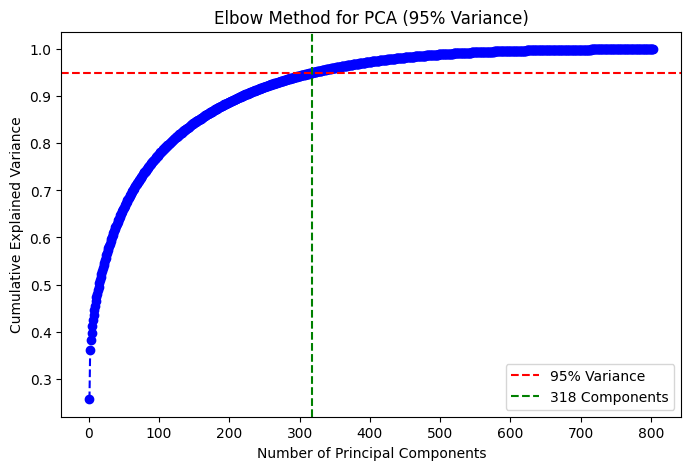

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axvline(x=num_components_95, color='g', linestyle='--', label=f'{num_components_95} Components')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Elbow Method for PCA (95% Variance)")
plt.legend()
plt.show()

In [48]:
pca_optimal = PCA(n_components=num_components_95)
X_pca = pca_optimal.fit_transform(X)


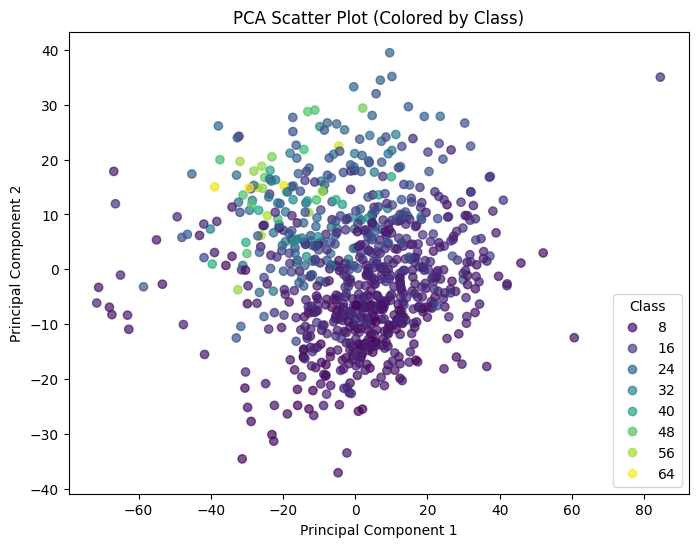

In [50]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", alpha=0.7)

plt.legend(*scatter.legend_elements(), title="Class")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot (Colored by Class)")
plt.show()

In [41]:
loadings = pca.components_
loadings_df = pd.DataFrame(loadings[:num_components_95].T, index=X.columns, columns=[f"PC{i+1}" for i in range(num_components_95)])
print("Top contributing regions for PC1:")
print(loadings_df["PC1"].abs().sort_values(ascending=False).head(10))

Top contributing regions for PC1:
fsVol_R_8BM_ROI      0.040219
fsLGI_R_s32_ROI      0.039759
fsArea_R_s32_ROI     0.039757
fsVol_L_13l_ROI      0.039690
fsArea_L_13l_ROI     0.039037
fsLGI_L_13l_ROI      0.039033
fsVol_L_8BM_ROI      0.038641
fsVol_R_STSva_ROI    0.038554
fsLGI_R_PI_ROI       0.038496
fsArea_R_PI_ROI      0.038489
Name: PC1, dtype: float64


### l1,l2 

In [54]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



ridge = Ridge(alpha=1.0) 
ridge.fit(X_pca, y)
y_pred_ridge = ridge.predict(X_pca)
print("Ridge MSE:", mean_squared_error(y, y_pred_ridge))


lasso = Lasso(alpha=0.1) 
lasso.fit(X_pca, y)
y_pred_lasso = lasso.predict(X_pca)
print("Lasso MSE:", mean_squared_error(y, y_pred_lasso))


elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)  
elastic.fit(X_pca, y)
y_pred_elastic = elastic.predict(X_pca)
print("Elastic Net MSE:", mean_squared_error(y, y_pred_elastic))


Ridge MSE: 15.510929688624232
Lasso MSE: 17.34282060981841
Elastic Net MSE: 16.2234947643395
